In [1]:
#Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
#Extracting CSV Dataset From System using Pandas Library
data=pd.read_csv('C:/Users/kushn/Downloads/Files/heart_disease_dataset.csv')
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
#All Columns in the Dataset
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [4]:
#Checking NULL Values
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:

target=data.groupby('target').size()
target


target
0    499
1    526
dtype: int64

In [6]:
#Converting Numerical data into Categorical Data
def heart_disease(row):
    if row==0:
        return 'Absence'
    elif row==1:
        return 'Presence'

In [7]:
#Applying converted data into our dataset with new colum- Heart_Disease
data['heart_disease']=data['target'].apply(heart_disease)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Absence
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Absence
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Absence
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Absence
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Absence


In [8]:
hd=data.groupby('heart_disease')['target'].count()
hd

heart_disease
Absence     499
Presence    526
Name: target, dtype: int64

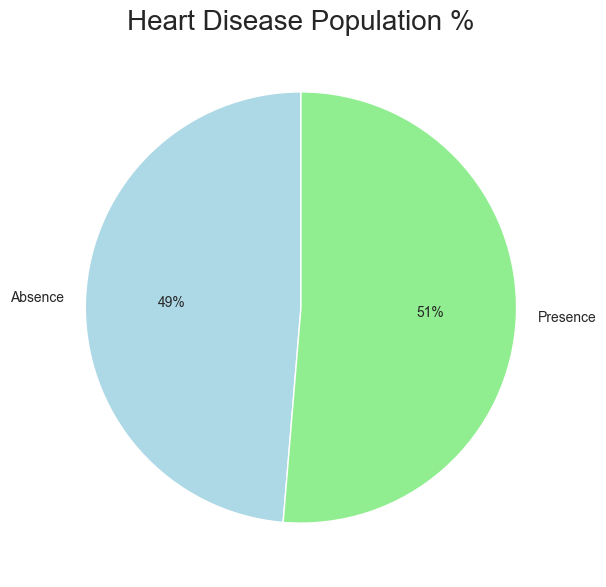

In [9]:
#Pie chart creation of Heart Disease Population % using Matplotlib
colors = [ 'lightblue', 'lightgreen']
plt.figure(figsize=(10,7))
plt.pie(hd, labels=['Absence','Presence'], autopct='%0.0f%%', colors=colors, startangle=90)
plt.title('Heart Disease Population %', fontsize=20)
plt.show()

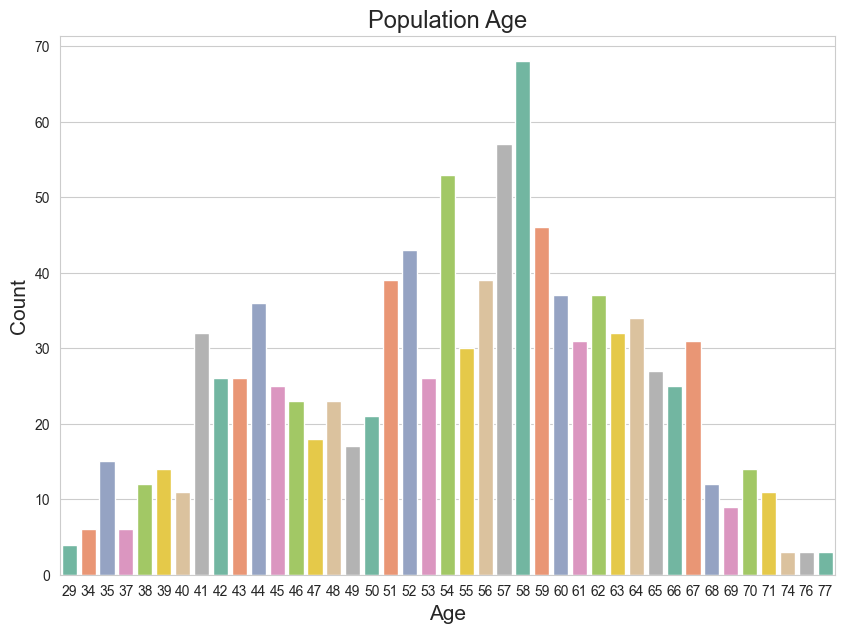

In [10]:
#Countplot Creation of Population Age using Matplotlib and Seaborn
plt.figure(figsize=(10,7))
sns.countplot(x='age', hue='age', data=data, palette='Set2', legend=False)
plt.title('Population Age', fontsize=17)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.show()

In [11]:
#Statistical Analsis
Min_Age=data['age'].min()
Max_Age=data['age'].max()
Mean_Age=data['age'].mean()
print("Minimum Age=",Min_Age)
print("Maximum Age=",Max_Age)
print("Mean Age=",Mean_Age)

Minimum Age= 29
Maximum Age= 77
Mean Age= 54.43414634146342


In [12]:
#categorical Analysis
Young_Ages=data[(data['age']>=29)&(data['age']<40)]
Middle_Ages=data[(data['age']>=40)&(data['age']<55)]
Elderly_Ages=data[(data['age']>55)]
print('Young Ages=',len(Young_Ages))
print('Middle Ages=',len(Middle_Ages))
print('Elderly Ages=',len(Elderly_Ages))

Young Ages= 57
Middle Ages= 419
Elderly Ages= 519


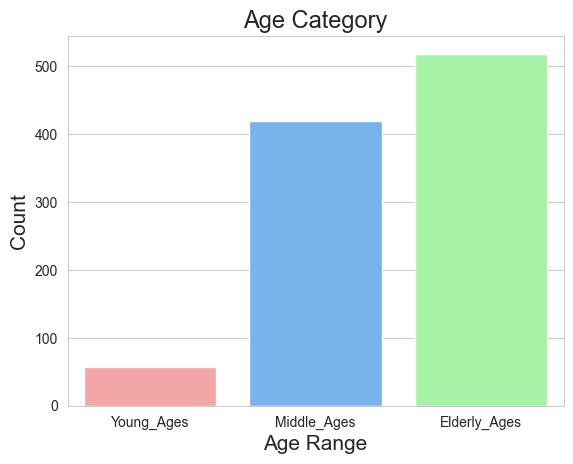

In [13]:
#Bur Plet creation of age Category using Matplotsib and Seaborn
sns.barplot(x=['Young_Ages', 'Middle_Ages', 'Elderly_Ages'], y=[len(Young_Ages), len(Middle_Ages), len(Elderly_Ages)], hue=['Young_Ages', 'Middle_Ages', 'Elderly_Ages'], palette=['#FF9999', '#66B3FF', '#99FF99'], legend=False)
plt.title('Age Category', fontsize=17)
plt.xlabel('Age Range', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.show()

In [14]:
#Converting Numerical Data into Categorical Data
def gender(row):
    if row==1:
        return 'Male'
    elif row==0:
        return 'Female'

In [15]:
#Applying Converted data into our dataset with new column- sex1
data['sex1']=data['sex'].apply(gender)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease,sex1
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Absence,Male
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Absence,Male
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Absence,Male
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Absence,Male
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Absence,Female


In [16]:
#Converting Numerical Data into Categorical Data
def age_range(row):
    if row>=29 and row<40:
        return 'Young Age'
    elif row>=40 and row<55:
        return 'Middle Age'
    elif row>55:
        return 'Elder Age'

In [17]:
#Applying Converted data into our dataset with new column- sex1
data['age_range']=data['age'].apply(age_range)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease,sex1,age_range
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Absence,Male,Middle Age
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Absence,Male,Middle Age
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Absence,Male,Elder Age
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Absence,Male,Elder Age
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Absence,Female,Elder Age


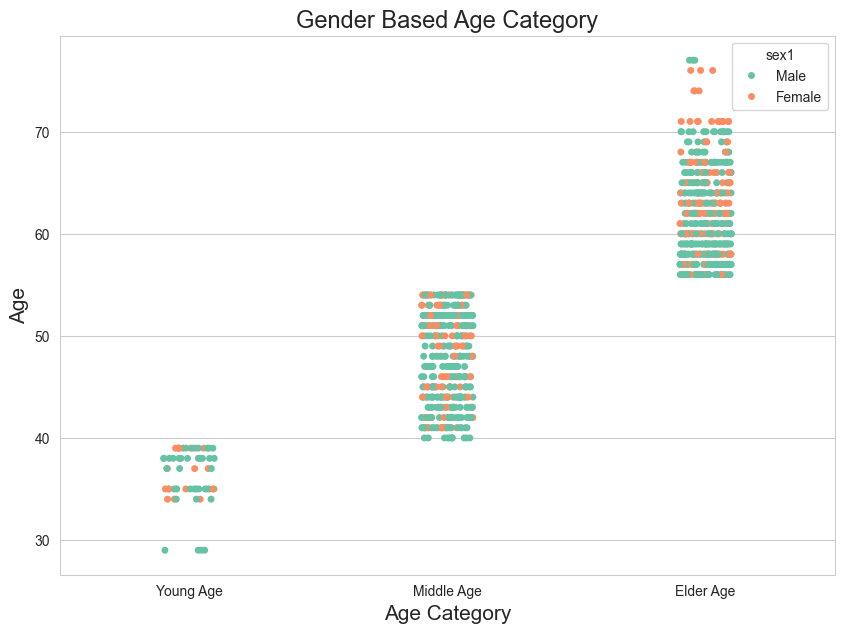

In [18]:
#StripPlot Creation of Gender Based Age Category using Matplotlib and Seaborn
plt.figure(figsize=(10,7))
sns.stripplot(x='age_range',y='age',hue='sex1',data=data,order=['Young Age','Middle Age','Elder Age'],palette='Set2')
plt.title('Gender Based Age Category', fontsize=17)
plt.xlabel('Age Category', fontsize=15)
plt.ylabel('Age', fontsize=15)
plt.show()

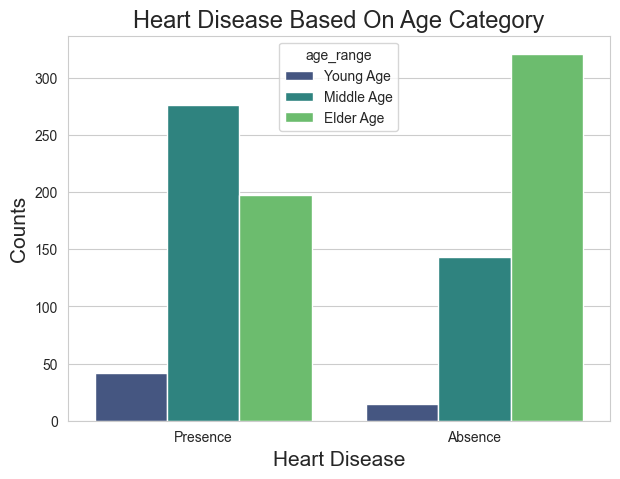

In [19]:
#Count plot creation of Heart Disease based on Age Category using matplotlib and seaborn
plt.figure(figsize=(7,5))
hue_order=['Young Age','Middle Age','Elder Age']
sns.countplot(x='heart_disease',hue='age_range',data=data,order=['Presence','Absence'],hue_order=hue_order,palette='viridis')
plt.title('Heart Disease Based On Age Category', fontsize=17)
plt.xlabel('Heart Disease', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.show()

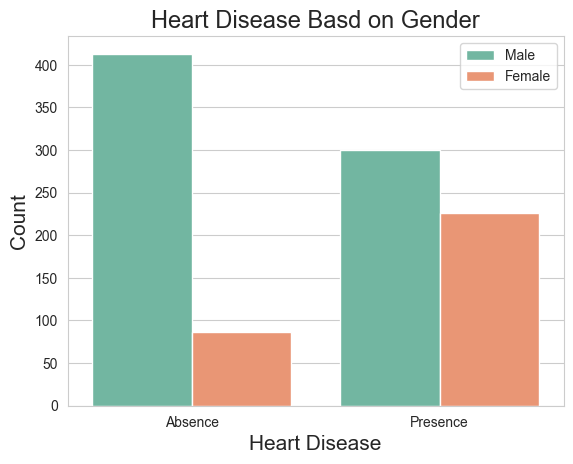

In [20]:
#Count plot creation of Heart disease based on Gender using matplotlib and seaborn
plt.figure(figure=(7,5))
sns.countplot(x=data['heart_disease'],hue='sex1',data=data,palette='Set2')
plt.xlabel('Heart Disease',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.legend(labels=['Male','Female'])
plt.title('Heart Disease Basd on Gender',fontsize=17)
plt.show()

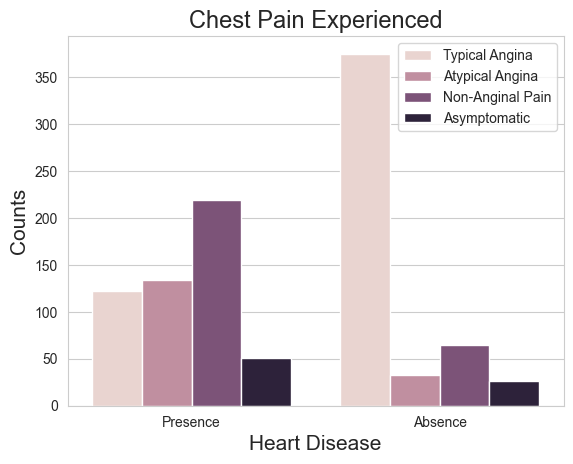

In [21]:
#Count plot creation of Chest Pain Experienced using Matplotlib and Seaborn
sns.countplot(x=data['heart_disease'],hue='cp',data=data,order=['Presence','Absence'])
plt.title('Chest Pain Experienced',fontsize=17)
plt.xlabel('Heart Disease',fontsize=15)
plt.ylabel('Counts',fontsize=15)
plt.legend(labels=['Typical Angina','Atypical Angina','Non-Anginal Pain','Asymptomatic'])
plt.show()

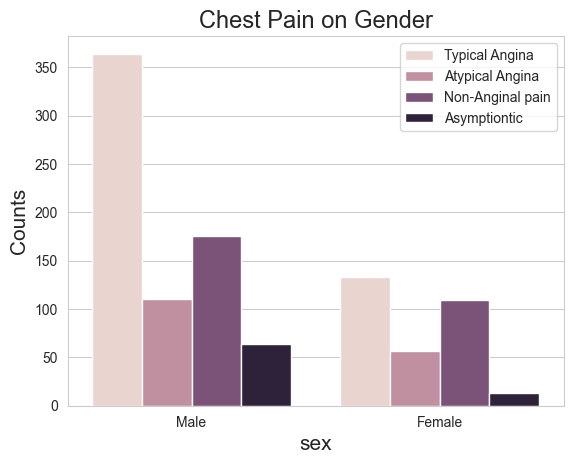

In [22]:
#Count plot Creation of Chest Pain based on gender using matloptlib and seaborn
sns.countplot(x=data['sex1'],hue='cp',data=data)
plt.title('Chest Pain on Gender',fontsize=17)
plt.xlabel('sex',fontsize=15)
plt.ylabel('Counts',fontsize=15)
plt.legend(labels=['Typical Angina','Atypical Angina','Non-Anginal pain','Asymptiontic'])
plt.show()

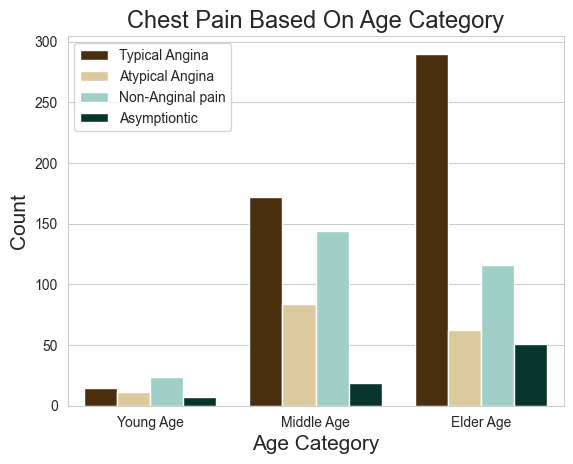

In [23]:
#count pl0ot creation of Chest Pain based on Age Category usong matplotlib and seaborn
sns.countplot(x=data['age_range'],hue='cp',data=data,order=['Young Age','Middle Age','Elder Age'],palette='BrBG')
plt.title('Chest Pain Based On Age Category',fontsize=17)
plt.xlabel('Age Category',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.legend(labels=['Typical Angina','Atypical Angina','Non-Anginal pain','Asymptiontic'])
plt.show()

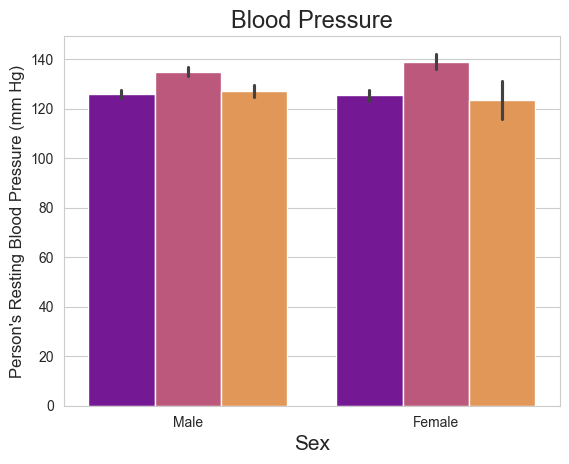

In [24]:
#Bar plot creation of person's resting blood pressure(mm Hg) using matplotlib and Seaborn
sns.barplot(x='sex1', y='trestbps', hue='age_range', data=data, palette='plasma', legend=False)
plt.title('Blood Pressure',fontsize=17)
plt.xlabel('Sex',fontsize=15)
plt.ylabel("Person's Resting Blood Pressure (mm Hg)",fontsize=12)
plt.show()

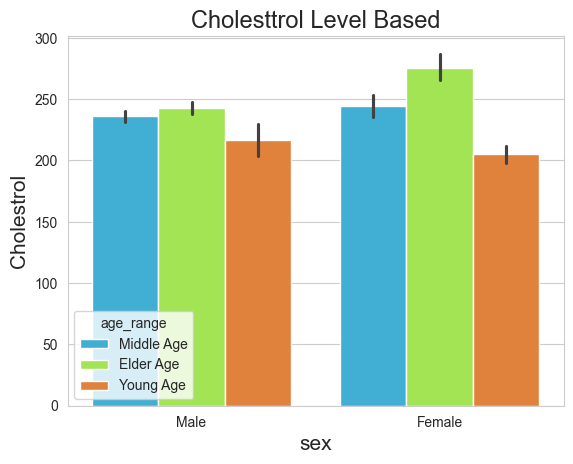

In [25]:
#Bar plot creation of Cholestrol level based on Cholesttrol Level using matplotlib and seaborn
sns.barplot(x='sex1', y='chol', hue='age_range', data=data, palette='turbo')
plt.title('Cholesttrol Level Based',fontsize=17)
plt.xlabel('sex',fontsize=15)
plt.ylabel('Cholestrol',fontsize=15)
plt.show()

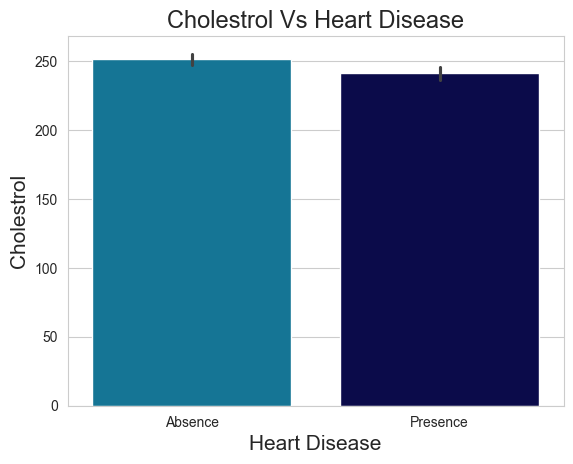

In [26]:
#Bar plot creation of Cholestrol level based on Cholestrol Vs Heart Disease using matplotlib and seaborn
sns.barplot(x='heart_disease', y='chol', hue='heart_disease', data=data, palette='ocean_r')
plt.title('Cholestrol Vs Heart Disease',fontsize=17)
plt.xlabel('Heart Disease',fontsize=15)
plt.ylabel('Cholestrol',fontsize=15)
plt.show()

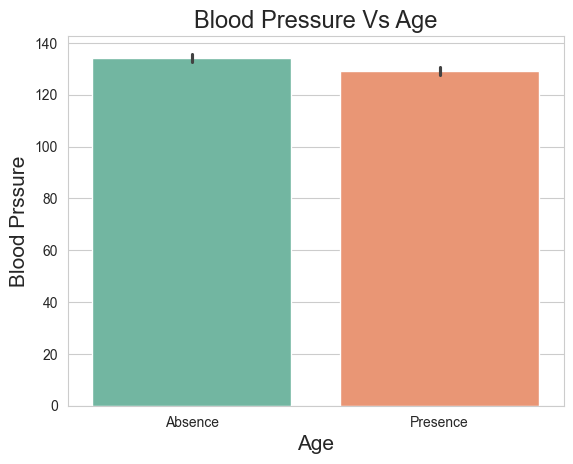

In [27]:
#Bar plot creation of Cholestrol level based on Blood Pressure Vs Age using matplotlib and seaborn
sns.barplot(x='heart_disease', y='trestbps', hue='heart_disease', data=data, palette='Set2')
plt.title('Blood Pressure Vs Age',fontsize=17)
plt.xlabel('Age',fontsize=15)
plt.ylabel('Blood Prssure',fontsize=15)
plt.show()

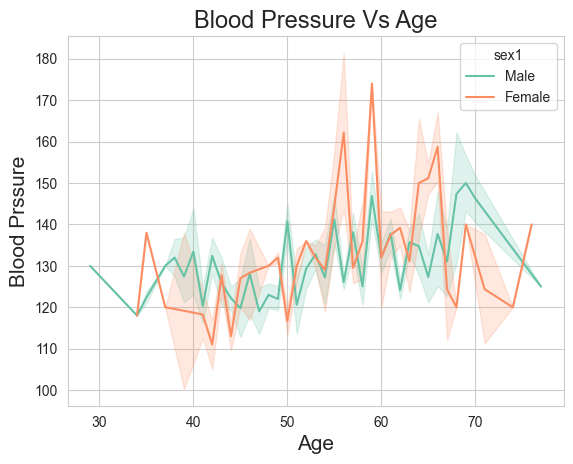

In [28]:
#line plot creation of Cholestrol level based on Blood Pressure Vs Age using matplotlib and seaborn
sns.lineplot(x='age', y='trestbps',hue='sex1',data=data, palette='Set2')
plt.title('Blood Pressure Vs Age',fontsize=17)
plt.xlabel('Age',fontsize=15)
plt.ylabel('Blood Prssure',fontsize=15)
plt.show()

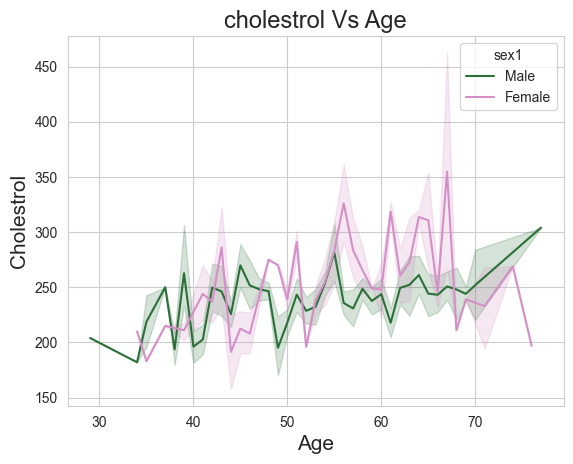

In [29]:
#line plot creation of Cholestrol level based on cholestrol Vs Age using matplotlib and seaborn
sns.lineplot(x='age', y='chol',hue='sex1',data=data, palette='cubehelix')
plt.title('cholestrol Vs Age',fontsize=17)
plt.xlabel('Age',fontsize=15)
plt.ylabel('Cholestrol',fontsize=15)
plt.show()

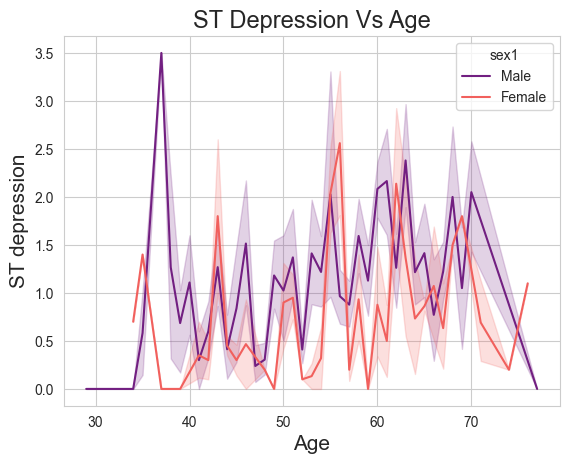

In [30]:
#line plot creation of Cholestrol level based on ST Depression Vs Age using matplotlib and seaborn
sns.lineplot(x='age', y='oldpeak',hue='sex1',data=data, palette='magma')
plt.title('ST Depression Vs Age',fontsize=17)
plt.xlabel('Age',fontsize=15)
plt.ylabel('ST depression',fontsize=15)
plt.show()

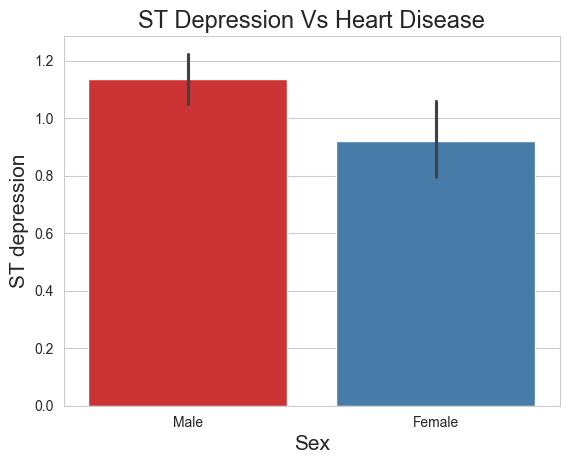

In [31]:
#bar plot creation of Cholestrol level based on ST Depression Vs Heart Disease using matplotlib and seaborn
sns.barplot(x='sex1', y='oldpeak',hue='sex1',data=data, palette='Set1')
plt.title('ST Depression Vs Heart Disease',fontsize=17)
plt.xlabel('Sex',fontsize=15)
plt.ylabel('ST depression',fontsize=15)
plt.show()

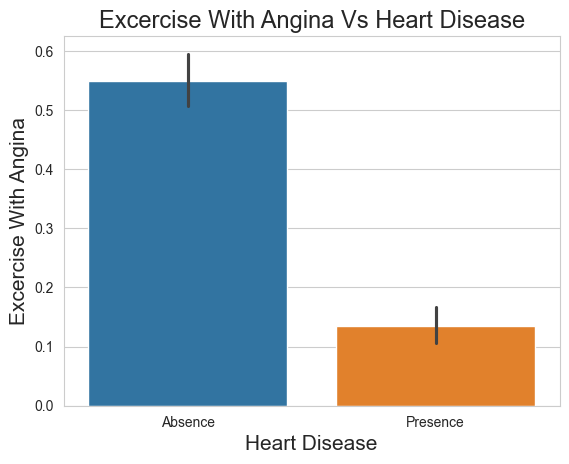

In [32]:
#Bar plot creation of Cholestrol level based Excercise With Angina Vs Heart Disease using matplotlib and seaborn
sns.barplot(x='heart_disease', y='exang',hue='heart_disease',data=data, palette='tab10')
plt.title('Excercise With Angina Vs Heart Disease',fontsize=17)
plt.xlabel('Heart Disease',fontsize=15)
plt.ylabel('Excercise With Angina',fontsize=15)
plt.show()

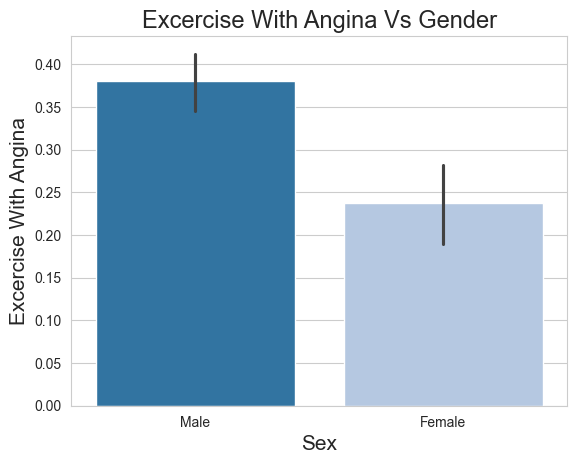

In [33]:
#Bar plot creation of Cholestrol level based Excercise With Angina Vs Gender using matplotlib and seaborn
sns.barplot(x='sex1', y='exang',hue='sex1',data=data, palette='tab20')
plt.title('Excercise With Angina Vs Gender',fontsize=17)
plt.xlabel('Sex',fontsize=15)
plt.ylabel('Excercise With Angina',fontsize=15)
plt.show()

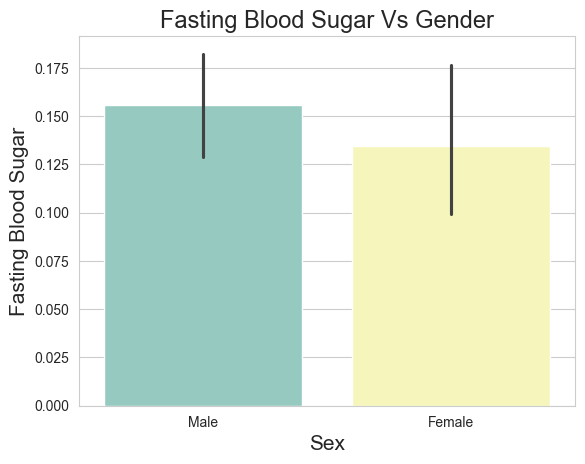

In [34]:
#Bar plot creation of Cholestrol level based Excercise With Angina Vs Gender using matplotlib and seaborn
sns.barplot(x='sex1', y='fbs',hue='sex1',data=data, palette='Set3')
plt.title('Fasting Blood Sugar Vs Gender',fontsize=17)
plt.xlabel('Sex',fontsize=15)
plt.ylabel('Fasting Blood Sugar',fontsize=15)
plt.show()

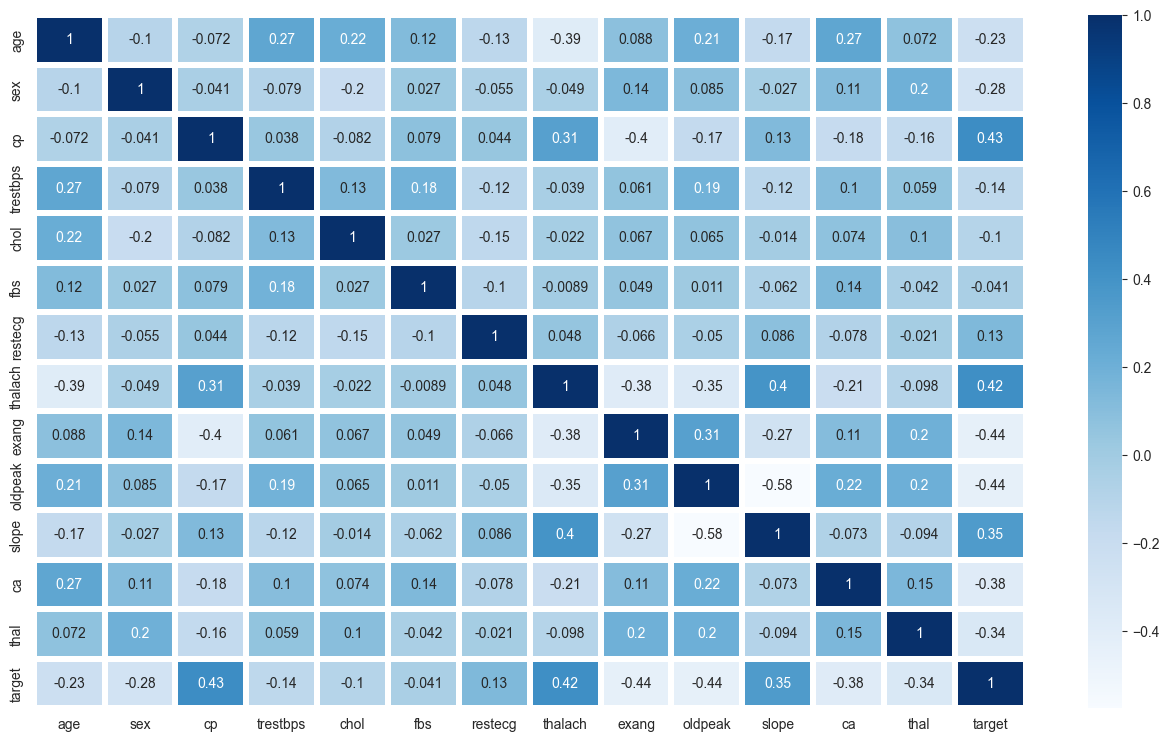

In [35]:
plt.figure(figsize=(16, 9))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot=True, linewidth=3, cmap='Blues')
plt.show()